# Time Series Forecasting — US Retail Clothing Sales
**EDHEC Business School — Time Series Course**

## Section 1 — Problem Definition

I forecast monthly US retail sales for clothing and accessory stores (FRED series MRTSSM448USN, obtained on https://fred.stlouisfed.org/series/MRTSSM448USN).  
The decision-maker is the CFO of a US clothing retail chain who needs a 12-month revenue outlook to plan inventory orders and staffing needs.  
Without a reliable forecast, the firm risks over-stocking slow months (January, February) and under-staffing peak months (November, December).

## Section 2 — Data Description and Preprocessing

In the part, I load the necessary librairies and the FRED monthly series.  
I inspect the data for missing values and outliers, and apply a log transformation to stabilise the variance before modelling.

In [ ]:
# Installations (depending on what you already have installed)
!pip install statsmodels
!pip install scikit-learn
!pip install pmdarima

In [2]:
# Librairies

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm

In [3]:
# Load the data
path='./'  # update path as needed 
df = pd.read_csv(path + "MRTSSM448USN.csv",
                 parse_dates=["observation_date"], index_col="observation_date")
df.index.freq = "MS" # after ida
series = df["MRTSSM448USN"].astype(float)

print("Data sample:")
series.head()


Data sample:


observation_date
1992-01-01    6734.0
1992-02-01    7302.0
1992-03-01    8245.0
1992-04-01    9152.0
1992-05-01    9294.0
Freq: MS, Name: MRTSSM448USN, dtype: float64

In [4]:
print(f"Time index: {df.index.freq} (monthly)") 
print(f"Range of timestamps : {series.index[0].strftime('%Y-%m')} -> {series.index[-1].strftime('%Y-%m')}")
print(f"Number of observations : {len(series)}")
print(f"Missing values : {series.isna().sum()}")

# define months for later (env variable)
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

Time index: <MonthBegin> (monthly)
Range of timestamps : 1992-01 -> 2025-11
Number of observations : 407
Missing values : 0


**Intermediary conclusion:**   

Range of timestamps : 1992-01 -> 2025-11  
Number of observations : 407  
Missing values : 0

### 2.1 Raw Series Plot

The plot below shows the full history of monthly clothing retail sales.  
One can already see three features:
- a clear upward long-term trend, 
- a strong and stable seasonal pattern repeating every 12 months (identifiable with the peaks), 
- and a massive shock in April–May 2020 caused by COVID-19 (store closures).   

I also see that the amplitude of the seasonal pattern grows with time (discussed in 2.2).

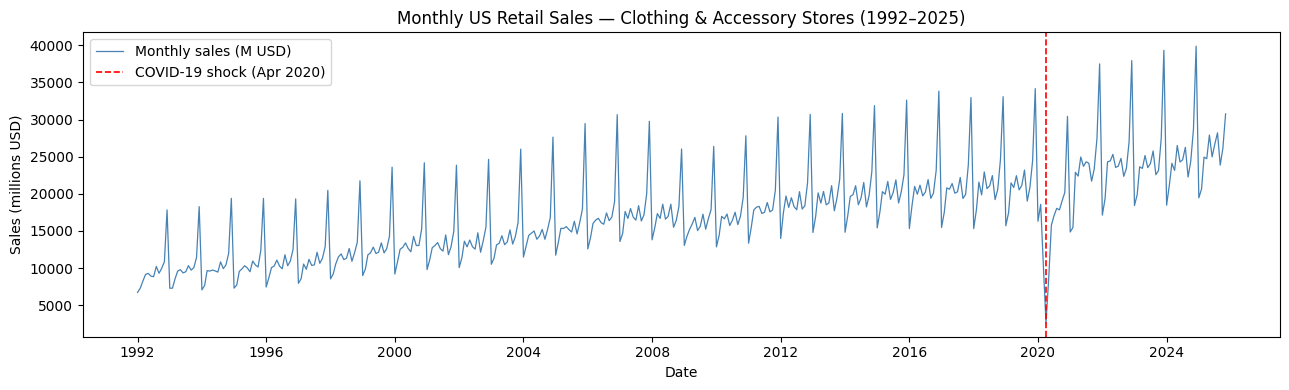

Extreme outliers (|z|>2.5, same-month comparison):
observation_date
2020-04-01    2631.0
Freq: MS

Top 3 values farthest from the center of the interval: 
observation_date
2020-04-01    2.654710
2025-11-01    2.100599
2025-08-01    2.068750
Name: MRTSSM448USN, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(series, color='steelblue', linewidth=0.9, label='Monthly sales (M USD)')
ax.axvline(pd.Timestamp('2020-04-01'), color='red', linestyle='--',
           linewidth=1.2, label='COVID-19 shock (Apr 2020)')
ax.set_title('Monthly US Retail Sales — Clothing & Accessory Stores (1992–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (millions USD)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# compare each observation to the median of the same calendar month
# this is robust to the COVID crash because I use median, not mean
monthly_median = series.groupby(series.index.month).transform('median')
monthly_std    = series.groupby(series.index.month).transform('std')
z = (series - monthly_median) / monthly_std
outliers = series[z.abs() > 2.5]
print(f"Extreme outliers (|z|>2.5, same-month comparison):\n{outliers.to_string()}")
print("\nTop 3 values farthest from the center of the interval: ")
print(z.abs().sort_values(ascending=False).head(3))


**Conclusion:**

Based on the interval of confidence used to detect outliers:

$$\text{Non-outlier condition: } 
x_t \in 
\left[
\operatorname{Median}_{m(t)}(x) - 2.5\,\operatorname{SD}_{m(t)}(x),\;
\operatorname{Median}_{m(t)}(x) + 2.5\,\operatorname{SD}_{m(t)}(x)
\right]
$$
$$
\text{Outlier if } x_t \notin \text{ this interval.}$$

I computed the z-scores for each point in the series:
$$z_t = \frac{x_t - \operatorname{Median}_{m(t)}(x)}{\operatorname{SD}_{m(t)}(x)}$$

$$\text{outlier}_t = 
\begin{cases}
1 & \text{if } |z_t| > 2.5\\
0 & \text{otherwise}
\end{cases}$$

And detected 1 outlier on 2020-04-01 (april 2020). That outlier had a z-score of 2.65.

### 2.2 Log Transformation

The seasonal pattern amplitude grow proportionally with the trend level.  
This measn the series is **multiplicative**. I will apply natural log to convert the series to an additive structure and stabilises the variance, which is required for ARIMA modelling (in part 3.4).  
But **I will still work on the raw data for decomposition in 3.3** (because one can).

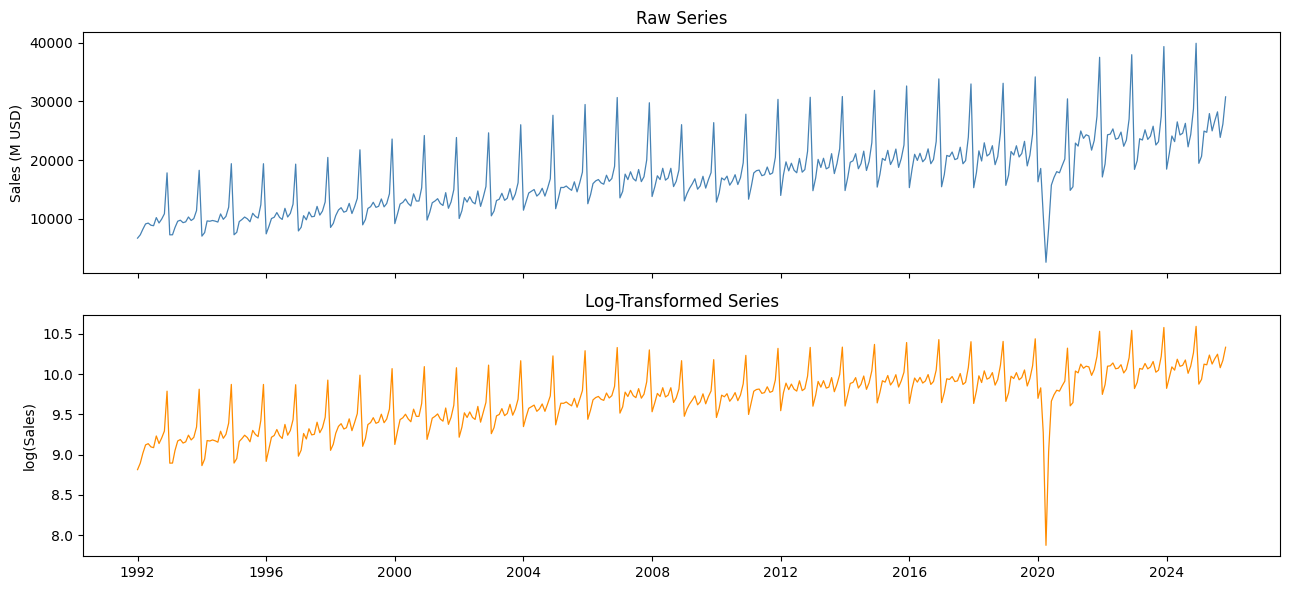

In [6]:
log_series = np.log(series)

# plot to see the change
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(series, color='steelblue', linewidth=0.9)
axes[0].set_title('Raw Series')
axes[0].set_ylabel('Sales (M USD)')
axes[1].plot(log_series, color='darkorange', linewidth=0.9)
axes[1].set_title('Log-Transformed Series')
axes[1].set_ylabel('log(Sales)')
axes[1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()



After log-transform, the seasonal waves are now roughly constant height, confirming that the variance is stabilised.

## Section 3 — Exploratory Analysis

I decompose the series, compute seasonal indices, measure the strength of each component, and test for stationarity.  
As mentioned, this can be done on the raw (multiplicative) series, so I leave the transformed series for later.

### 3.1 Classical Multiplicative Decomposition

Because the seasonal amplitude grows with the trend level, I apply a **multiplicative** decomposition to see its components: $$(y_t = T_t × S_t × R_t)$$
The four subplots show the original series, the trend (extracted by a centred 12-month moving average), the seasonal component, and the residual.

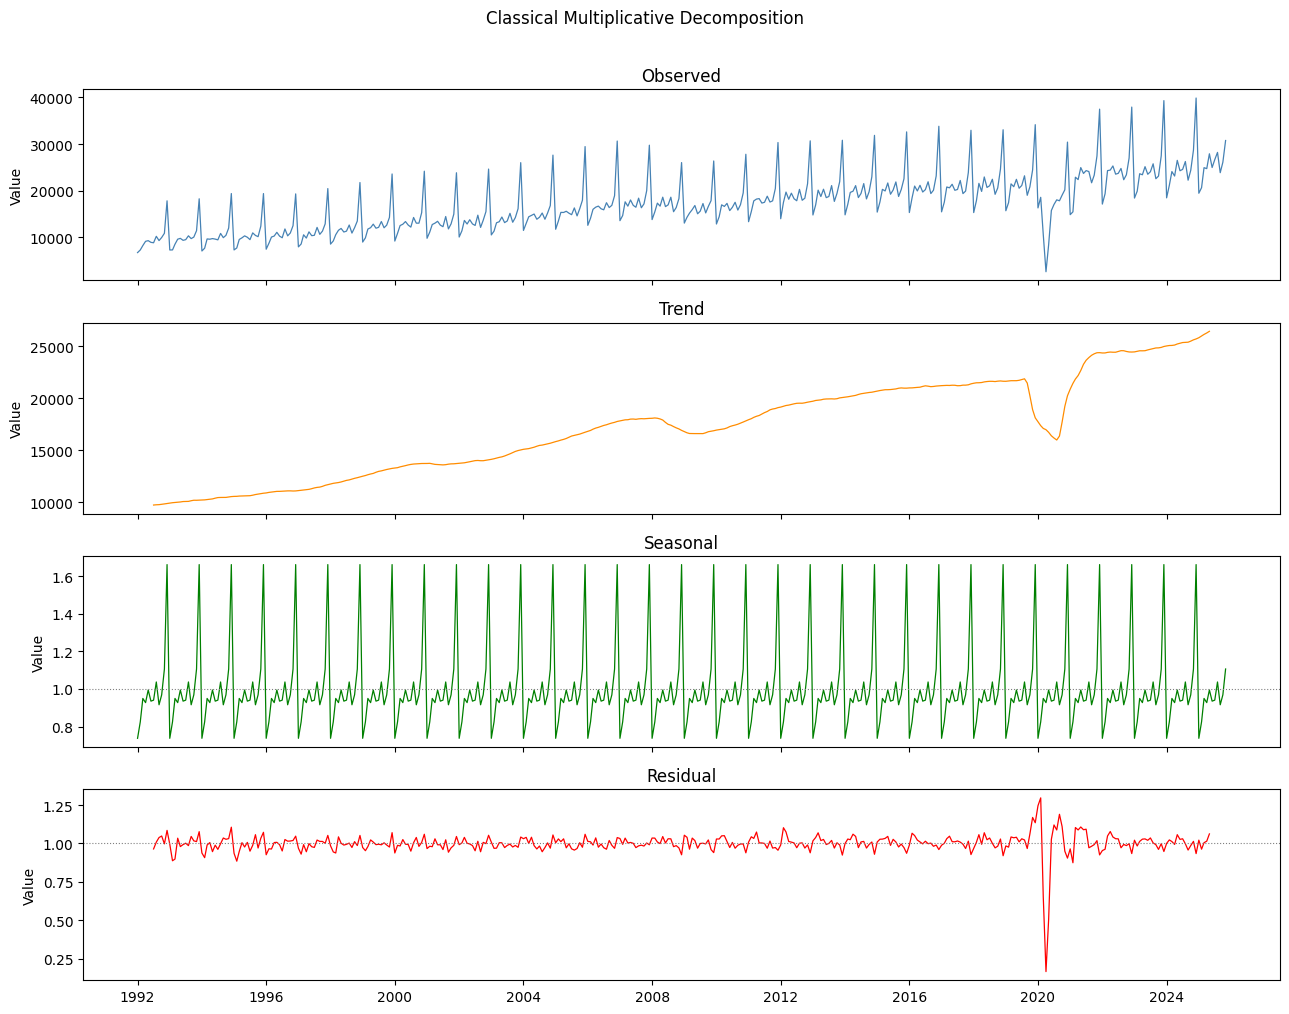

In [7]:
decomp = seasonal_decompose(series, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, data, title, color in zip(axes,
        [series, decomp.trend, decomp.seasonal, decomp.resid],
        ['Observed', 'Trend', 'Seasonal', 'Residual'],
        ['steelblue', 'darkorange', 'green', 'red']):
    ax.plot(data, color=color, linewidth=0.9)
    ax.set_title(title)
    ax.set_ylabel('Value')
    if title in ('Seasonal', 'Residual'):
        ax.axhline(1.0, color='grey', linestyle=':', linewidth=0.8)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Classical Multiplicative Decomposition', y=1.01)
plt.tight_layout()
plt.show()


**Observations:**  
- Trend is strongly upward and relatively smooth up to 2020
- Seasonality shows stable wave pattern with December as the annual peak
- Residual spikes clearly in 2020, confirming COVID as the main anomaly as as seen in outlier detection.

### 3.2 Seasonal Indices

I compute the normalised seasonal indices.  
They must sum to 12 for a monthly multiplicative model.  
Values above 1 indicate months where sales are above average; values below 1 indicate below-average months.

Normalised Seasonal Indices  (sum = 12.0000):
  Jan: 0.7378
  Feb: 0.8253
  Mar: 0.9497
  Apr: 0.9275
  May: 0.9945
  Jun: 0.9353
  Jul: 0.9406
  Aug: 1.0372
  Sep: 0.9160
  Oct: 0.9689
  Nov: 1.1061
  Dec: 1.6609


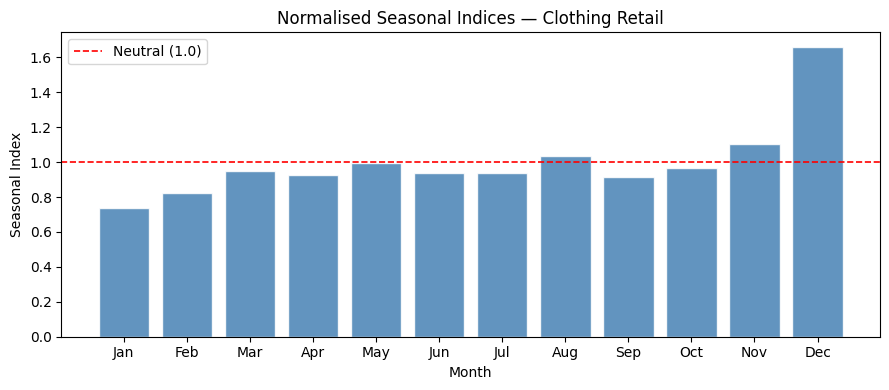

In [8]:
# average seasonal factor for each calendar month, then normalise
monthly_avg = {m: decomp.seasonal[decomp.seasonal.index.month == m].mean()
               for m in range(1, 13)}
si = pd.Series(monthly_avg)
si_norm = si / si.mean()   # normalise so mean=1, sum=12

print(f"Normalised Seasonal Indices  (sum = {si_norm.sum():.4f}):")
for i, (m, v) in enumerate(si_norm.items()):
    print(f"  {MONTH_NAMES[i]:>3}: {v:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(MONTH_NAMES, si_norm.values, color='steelblue', alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Neutral (1.0)')
ax.set_title('Normalised Seasonal Indices — Clothing Retail')
ax.set_xlabel('Month')
ax.set_ylabel('Seasonal Index')
ax.legend()
plt.tight_layout()
plt.show()

# December peaks well above 1 — typical holiday season surge
# January/February are the weakest months — post-holiday slump

The bar chart confirms a strong and stable seasonal pattern in clothing retail sales.  
December stands out with an index of ~1.65, because of the holiday shopping surge. Sales are 65% above the monthly average.  
And January and February are the weakest months (indices ~0.73 and ~0.81), probably because of the post-holiday demand collapse (makes sense in clothing retail).

### 3.3 Strength of Trend and Seasonality

Following the course formula, strenght of compoentn is given by: $$F = max(0, 1 − \frac{Var(R)}{Var(component + R)})$$
where R is the remainder.  
Values close to 1 mean the component dominates; values close to 0 mean the component is weak relative to noise.

In [9]:
remainder = decomp.resid.dropna()
trend_c   = decomp.trend.dropna()
idx = remainder.index.intersection(trend_c.index)
R = remainder[idx]; T = trend_c[idx]; S = decomp.seasonal[idx]

F_trend  = max(0.0, 1 - R.var() / (T + R).var())
F_season = max(0.0, 1 - R.var() / (S + R).var())

print(f"Strength of Trend       : F_T = {F_trend:.4f}")
print(f"Strength of Seasonality : F_S = {F_season:.4f}")

Strength of Trend       : F_T = 1.0000
Strength of Seasonality : F_S = 0.9104


**Observation:**  
Very strong trend and very strong seasonality.  
- The trend strength F_T = 1.00 indicates that the variance of the remainder is super small compared to the variance of trend + remainder.  
In other words, there is almost no noise relatively to the long-run trend.  
- The seasonality strength F_S = 0.91 is also very high, confirming that the seasonal pattern is a reliable, recurring feature of the series and not random fluctuation.  

**Conclusion:**  
Decomposition alone is not sufficient for forecasting, because it is backward-looking and cannot extrapolate or give prediction intervals.  
The above results justify using a model that explicitly handles both components for forecasting, such as maybe ETS(A,Ad,M) or SARIMA.

### 3.4 Stationarity Tests

ARIMA modelling requires a stationary series. I apply the ADF test (H₀: series is non-stationary) and the KPSS test (H₀: series stationary).  
A series is confirmed stationary when ADF p < 0.05 and KPSS p > 0.05.  
I apply these tests on the log-series.  

In [10]:
warnings.filterwarnings("ignore", category=UserWarning)
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [11]:
def run_adf(ts, label):
    res = adfuller(ts.dropna(), autolag='AIC')
    status = 'STATIONARY' if res[1] < 0.05 else 'NON-STATIONARY'
    print(f"ADF  [{label}]  stat={res[0]:.3f}  p={res[1]:.4f}  → {status}")

def run_kpss(ts, label):
    res = kpss(ts.dropna(), regression='c', nlags='auto')
    status = 'STATIONARY' if res[1] > 0.05 else 'NON-STATIONARY'
    print(f"KPSS [{label}]  stat={res[0]:.3f}  p={res[1]:.4f}  → {status}")

run_adf(log_series,  'log level'); run_kpss(log_series,  'log level')
print()
log_d1 = log_series.diff(1).dropna()
run_adf(log_d1,      'log d=1');   run_kpss(log_d1,      'log d=1')
print()
log_d1_D1 = log_d1.diff(12).dropna()
run_adf(log_d1_D1,   'log d=1 D=1'); run_kpss(log_d1_D1, 'log d=1 D=1')

ADF  [log level]  stat=-1.217  p=0.6664  → NON-STATIONARY
KPSS [log level]  stat=3.180  p=0.0100  → NON-STATIONARY



ADF  [log d=1]  stat=-7.507  p=0.0000  → STATIONARY
KPSS [log d=1]  stat=0.210  p=0.1000  → STATIONARY

ADF  [log d=1 D=1]  stat=-8.387  p=0.0000  → STATIONARY
KPSS [log d=1 D=1]  stat=0.072  p=0.1000  → STATIONARY


**Conclusion:**   
- The log-level series is clearly non-stationary: the ADF fails to reject its null (p = 0.67) and the KPSS rejects its null (p = 0.01),  
so both tests agree that the series has a drifting mean and cannot be used directly in ARIMA.
- After one first difference (d=1), both tests confirm stationarity: ADF p ≈ 0.00 and KPSS p = 0.10, meaning the trend is fully removed by differencing once.
- Adding the seasonal difference (D=1) keeps the series stationary and removes the remaining seasonal pattern, giving us the input required for SARIMA
identification.  

Note: extrapolation warnings on the KPSS were silenced — they were not problematic, simply indicating that values were truncated.

### 3.5 Verification with Differenced Series, and ACF / PACF

The plots below show the progression toward stationarity. After one first difference and one seasonal difference (d=1, D=1, m=12), the series fluctuates around zero with no visible trend or seasonal pattern.

On the ACF / PACF I then look for spikes to identify the SARIMA order: a cut-off in the ACF at lag k → MA(k); a cut-off in the PACF at lag k → AR(k); spikes at lag 12 → seasonal terms.

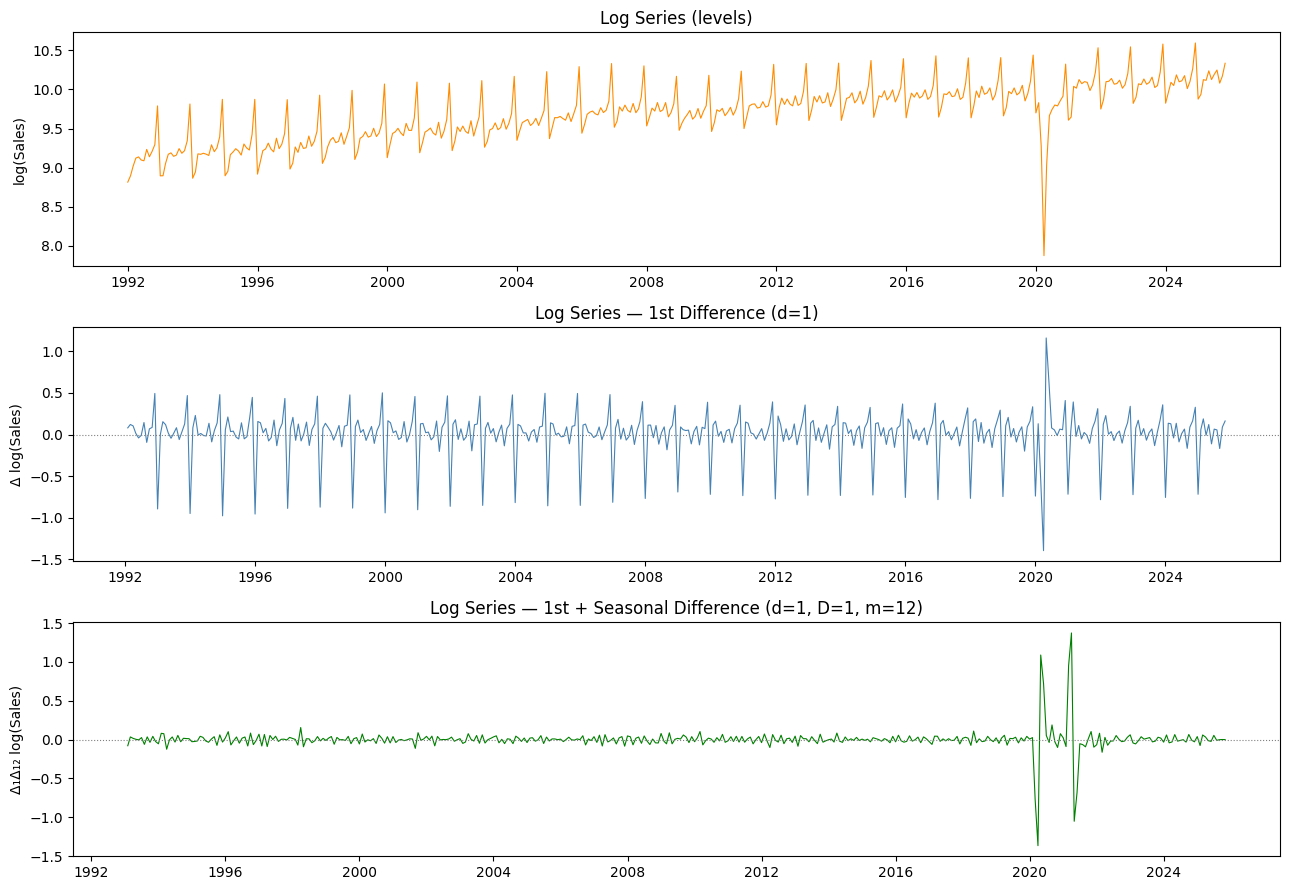

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
axes[0].plot(log_series,  color='darkorange', linewidth=0.8)
axes[0].set_title('Log Series (levels)')
axes[0].set_ylabel('log(Sales)')
axes[1].plot(log_d1,      color='steelblue',  linewidth=0.8)
axes[1].axhline(0, color='grey', linestyle=':', linewidth=0.8)
axes[1].set_title('Log Series — 1st Difference (d=1)')
axes[1].set_ylabel('Δ log(Sales)')
axes[2].plot(log_d1_D1,   color='green',      linewidth=0.8)
axes[2].axhline(0, color='grey', linestyle=':', linewidth=0.8)
axes[2].set_title('Log Series — 1st + Seasonal Difference (d=1, D=1, m=12)')
axes[2].set_ylabel('Δ₁Δ₁₂ log(Sales)')
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


As discussed before: d=1 removes the upward trend; D=1 removes the seasonal wave. The COVID spike in 2020 remains as the only visible anomaly

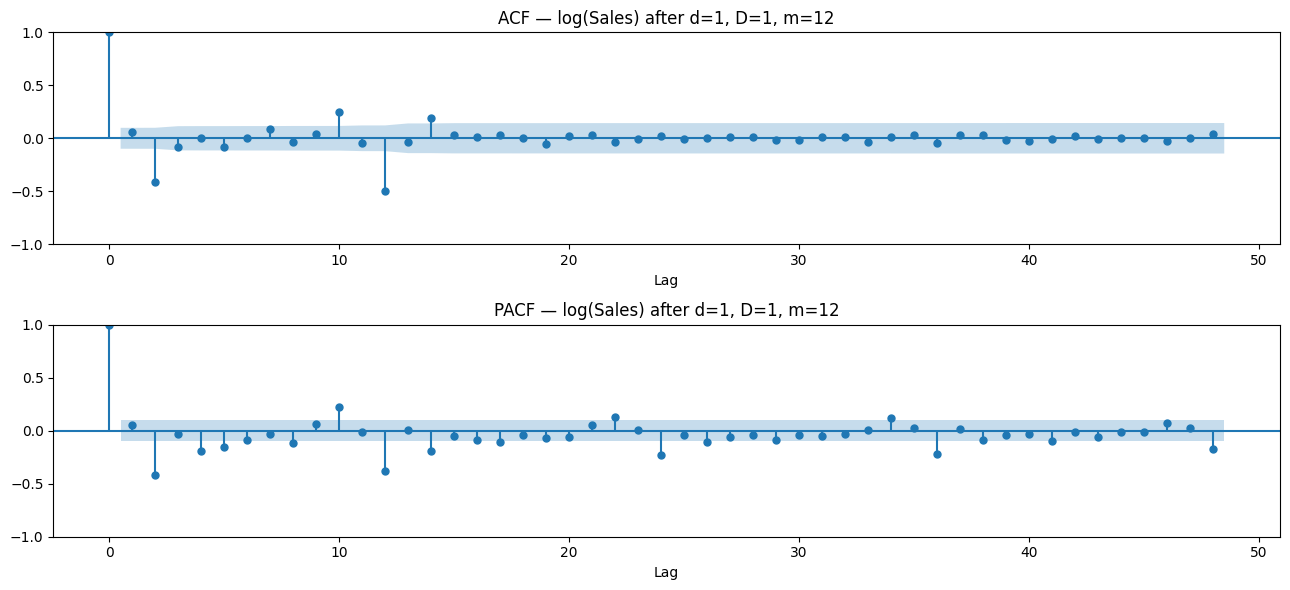

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
plot_acf( log_d1_D1, lags=48, ax=axes[0],
          title='ACF — log(Sales) after d=1, D=1, m=12')
plot_pacf(log_d1_D1, lags=48, ax=axes[1],
          title='PACF — log(Sales) after d=1, D=1, m=12', method='ywm')
axes[0].set_xlabel('Lag'); axes[1].set_xlabel('Lag')
plt.tight_layout()
plt.show()


**Observations:** 

- Both plots are almost entirely flat after lag 2, which confirms that the two rounds of differencing successfully cleaned the series.  
- The spikes at lag 2 in both plots suggest the model needs a short-memory MA or AR term to capture the remaining month-to-month correlation.  
- The large spike at lag 12 in both plots signals that a seasonal term is still needed, which is not abnormal for monthly retail data.  

I will let auto_arima test all combinations of (p, q, P, Q) to select the best one by AIC in the next section.

## Section 4 — Forecasting Models

I held out the last 24 months as a test set and fit three models on the training data.  

In [14]:
TEST_SIZE = 24
train     = series.iloc[:-TEST_SIZE]
test      = series.iloc[-TEST_SIZE:]
train_log = log_series.iloc[:-TEST_SIZE]

print(f"Train : {train.index[0].strftime('%Y-%m')} → {train.index[-1].strftime('%Y-%m')}  ({len(train)} obs)")
print(f"Test  : {test.index[0].strftime('%Y-%m')} → {test.index[-1].strftime('%Y-%m')}  ({len(test)} obs)")

Train : 1992-01 → 2023-11  (383 obs)
Test  : 2023-12 → 2025-11  (24 obs)


### 4.1 Model 1 — Naïve Seasonal - Benchmark

The naïve seasonal model sets each forecast equal to the value observed in the same month of the previous year: $$ŷ(t) = y(t−12)$$
This model is fitted on the raw data.
It requires no estimation and serves as a baseline that the more sophisticated models should outperform.

In [15]:
# repeat the last observed year to cover the 24-month test window
naive_pred = np.tile(train.iloc[-12:].values,
                     int(np.ceil(TEST_SIZE / 12)))[:TEST_SIZE]
naive_pred = pd.Series(naive_pred, index=test.index)

# in-sample residuals: y(t) - y(t-12)
naive_insample_resid = series.diff(12).dropna()
print("Naïve seasonal benchmark prepared.")

Naïve seasonal benchmark prepared.


### 4.2 Model 2 — Holt-Winters with damping - ETS(A,Ad,M)

I fit an exponential smoothing model (on the raw multiplicative data as well) with additive errors, an additive **damped** trend, and multiplicative seasonality.  
I choose a damped trend because Holt's linear trend tends to over-project sales growth in far horizon h (eg longer than 12 units), and I want to predict 24 months here.  
The damping parameter $\Phi$ pulls long-range forecasts toward a flat asymptote, which is more realistic for retail revenue.

In [16]:
ets_model = ExponentialSmoothing(
    train,
    trend='add',
    damped_trend=True,       # prevents the trend from projecting too aggressively
    seasonal='mul',          # multiplicative: seasonal amplitudes scale with the level
    seasonal_periods=12,
    initialization_method='estimated'
)
ets_fit  = ets_model.fit(optimized=True)
ets_pred = ets_fit.forecast(TEST_SIZE)
ets_pred.index = test.index

print("Holt-Winters model fitted.")
print(f"alpha (level)    : {ets_fit.params['smoothing_level']:.4f}")
print(f"beta  (trend)    : {ets_fit.params['smoothing_trend']:.4f}")
print(f"gamma (seasonal) : {ets_fit.params['smoothing_seasonal']:.4f}")
print(f"phi   (damping)  : {ets_fit.params['damping_trend']:.4f}")

Holt-Winters model fitted.
alpha (level)    : 1.0000
beta  (trend)    : 0.0000
gamma (seasonal) : 0.0000
phi   (damping)  : 0.9950


**Commentary:**
- high alpha = model is reactive to recent level changes  
Alpha = 1.0 means the level actually updates entirely from the latest observation, which makes sense given how strongly the series trends.  

- low beta/gamma = trend and seasonality update slowly 
Beta = 0.0 and gamma = 0.0 mean the trend and seasonal indices are kept entirely fixed, which is justified by the very stable seasonality (F_S = 0.91) I measured earlier.  

- Phi = 0.995 means the model applies a very slight damping so that long-range forecasts flatten with time rather than growing forever.  

These parameters are all reasonable and expected for this dataset.

### 4.3 Model 3 — SARIMA

I use `auto_arima` with d=1 and D=1 (fixed from the earlier stationarity tests) to select the optimal order by AIC.  
**This model is fitted on the log-transformed series** and forecasts are back-transformed with `exp()` to return to the original scale.

In [17]:
# auto_arima searches over (p,q) and (P,Q) using AIC — d=1 and D=1 fixed
print("Running auto_arima:")
auto_result = pm.auto_arima(
    train_log,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=1, D=1, m=12,
    information_criterion='aic',
    stepwise=True,
    seasonal=True,
    trace=True,
    suppress_warnings=True
)
p, d, q     = auto_result.order
P, D, Q, ms = auto_result.seasonal_order
print(f"\nauto_arima selected: SARIMA({p},{d},{q})({P},{D},{Q})[12]")

Running auto_arima:
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-313.141, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-414.264, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-521.695, Time=0.39 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-317.290, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-520.315, Time=0.83 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-520.418, Time=1.69 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-416.569, Time=0.15 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-524.543, Time=2.47 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=-524.323, Time=2.48 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=-519.582, Time=1.14 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=-526.363, Time=1.84 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=-522.205, Time=1.35 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=-522.083, Time=0.33 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=-526.056, Time=2.33 sec

**Commentary:**  

auto_arima selected: SARIMA(3,1,1)(0,1,1)[12]  

- The non-seasonal part ARIMA(3,1,1) means the model uses the past 3 months of values and the past forecast error to predict the next month, after removing the trend via
first differencing.  
- The seasonal part (0,1,1)[12] means no seasonal AR term was needed: one seasonal MA term and one seasonal difference were sufficient to capture the yearly pattern.  
This is consistent with what as seen in the ACF/PACF: a spike at lag 12 but no gradual seasonal decay that would require a seasonal AR term.

In [18]:
sarima_model = SARIMAX(
    train_log,
    order=(p, d, q),
    seasonal_order=(P, D, Q, ms),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# back-transform from log scale to original (millions USD)
sarima_log_pred = sarima_fit.forecast(TEST_SIZE)
sarima_pred     = np.exp(sarima_log_pred)
sarima_pred.index = test.index

sarima_label = f"SARIMA({p},{d},{q})({P},{D},{Q})[12]"

                                     SARIMAX Results                                      
Dep. Variable:                       MRTSSM448USN   No. Observations:                  383
Model:             SARIMAX(3, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 295.221
Date:                            Wed, 04 Mar 2026   AIC                           -578.441
Time:                                    13:33:54   BIC                           -555.192
Sample:                                01-01-1992   HQIC                          -569.193
                                     - 11-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8600      0.034     25.533      0.000       0.794       0.926
ar.L2         -0.3986      0.078   

**Analysis:**  
- All coefficients are significant (p = 0.000)  

- the Ljung-Box p = 0.88 confirms the residuals are white noise, so the model has captured all the structure in the data  

- One can note one issue which is the extreme kurtosis (119.74) and skew (-8.18). These are caused by the COVID crash creating one huge outlier residual.  
This can be problematic for prediction intervals, because the SARIMA model assumes residuals are symmetric and well-behaved when calculating the forecast uncertainty range -> since they are apparently not, the model will underestimate how wide that range should be, making the intervals too narrow and overconfident.  
Since the COVID crash is in the training data, this affects the parameter estimates and the residual distribution.


## Section 5 — Forecast Evaluation

I evaluate the models using expanding-window cross-validation (5 folds, 12-month horizon each) and then compute test-set accuracy metrics (RMSE, MAE) and the Ljung-Box test on in-sample residuals to check model validity.

### 5.1 Time Series Cross-Validation

Expanding-window CV starts with a minimum training window and extends it by one fold at each step. Each fold forecasts 12 months ahead. This mimics real deployment conditions: training always on past data and forecasting the future.

In [19]:
N_FOLDS    = 5
CV_HORIZON = 12
min_train  = len(train) - N_FOLDS * CV_HORIZON

cv_rmse = {'Naive': [], 'ETS': [], 'SARIMA': []}
cv_mae = {'Naive': [], 'ETS': [], 'SARIMA': []}

for fold in range(N_FOLDS):
    t_end    = min_train + fold * CV_HORIZON
    cv_train = series.iloc[:t_end]
    cv_test  = series.iloc[t_end : t_end + CV_HORIZON]

    # Naive: repeat last 12 observations of the training window
    naive_cv = cv_train.iloc[-12:].values
    cv_rmse['Naive'].append(np.sqrt(mean_squared_error(cv_test.values, naive_cv)))
    cv_mae['Naive'].append(mean_absolute_error(cv_test.values, naive_cv))

    # ETS same spec as final model
    ets_cv = ExponentialSmoothing(
        cv_train, trend='add', damped_trend=True,
        seasonal='mul', seasonal_periods=12,
        initialization_method='estimated'
    ).fit(optimized=True)
    cv_rmse['ETS'].append(
        np.sqrt(mean_squared_error(cv_test.values, ets_cv.forecast(CV_HORIZON).values)))
    cv_mae['ETS'].append(
        mean_absolute_error(cv_test.values, ets_cv.forecast(CV_HORIZON).values))

    # SARIMA on log scale, same order as final model
    sarima_cv = SARIMAX(
        np.log(cv_train), order=(p,d,q),
        seasonal_order=(P,D,Q,ms),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    sarima_cv_fc = np.exp(sarima_cv.forecast(CV_HORIZON))
    cv_rmse['SARIMA'].append(
        np.sqrt(mean_squared_error(cv_test.values, sarima_cv_fc.values)))
    cv_mae['SARIMA'].append(
        mean_absolute_error(cv_test.values, sarima_cv_fc.values))

    print(f"Fold {fold+1} done")

print("\nCV RMSE by fold:")
cv_df = pd.DataFrame(cv_rmse, index=[f"Fold {i+1}" for i in range(N_FOLDS)])
cv_df.loc["Mean"] = cv_df.mean()
cv_df = cv_df.round(1)
print(cv_df)

print("\nCV MAE by fold:")
cv_df2 = pd.DataFrame(cv_mae, index=[f"Fold {i+1}" for i in range(N_FOLDS)])
cv_df2.loc["Mean"] = cv_df2.mean()
cv_df2 = cv_df2.round(1)
print(cv_df2)

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

CV RMSE by fold:
         Naive     ETS  SARIMA
Fold 1   443.8   522.9   520.9
Fold 2  7847.0  7969.4  7909.2
Fold 3  9486.0  5144.1  8864.5
Fold 4  2546.5  1382.4  3482.2
Fold 5   653.6   786.6  1969.7
Mean    4195.4  3161.1  4549.3

CV MAE by fold:
         Naive     ETS  SARIMA
Fold 1   348.1   410.5   430.5
Fold 2  5597.7  5649.7  5627.0
Fold 3  7799.0  4597.5  7657.3
Fold 4  1631.8  1137.0  2668.1
Fold 5   537.8   654.2  1483.1
Mean    3182.9  2489.8  3573.2


**Commentary:**  

The CV results show very high variance across folds: fold 2 and 3 record RMSE values around 8000-9000 for all three models, which are certainly the folds
covering the COVID period (2020-2022).  
This inflates the mean RMSE for all models and makes comparison difficult.  
Looking at the MAEs, which are less sensitive to those extreme errors, the ranking is the same but the gap is clearer: ETS (2490) comfortably leads Naive (3183) and SARIMA (3573).  
Outside of those problematic folds, ETS wins with the lowest mean CV RMSE (3161) outperforms both Naive (4195) and SARIMA (4549).

### 5.2 Test-Set Accuracy and Model Validity

I report RMSE and MAE on the 24-month hold-out set. I also run the Ljung-Box test at lag 24 on in-sample residuals: a p-value above 0.05 means residuals are white noise (model is valid). A model with lower error but autocorrelated residuals should be discarded — accuracy is meaningless without validity.

In [20]:
def rmse(y, yhat): return np.sqrt(mean_squared_error(y, yhat))
def mae(y, yhat):  return mean_absolute_error(y, yhat)
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100
def lb_p(resid):
    return acorr_ljungbox(resid.dropna(), lags=[24], return_df=True)['lb_pvalue'].values[0]

rmse_n, mae_n, mape_n = rmse(test, naive_pred),  mae(test, naive_pred),  mape(test, naive_pred)
rmse_e, mae_e, mape_e = rmse(test, ets_pred),    mae(test, ets_pred),    mape(test, ets_pred)
rmse_s, mae_s, mape_s = rmse(test, sarima_pred), mae(test, sarima_pred), mape(test, sarima_pred)

lb_n = lb_p(naive_insample_resid)
lb_e = lb_p(pd.Series(ets_fit.resid.values,    index=train.index))
lb_s = lb_p(pd.Series(sarima_fit.resid.values, index=train_log.index))

summary = pd.DataFrame({
    'Model'        : ['Naive Seasonal', 'ETS(A,Ad,M)', sarima_label],
    'RMSE'         : [round(rmse_n,1), round(rmse_e,1), round(rmse_s,1)],
    'MAE'          : [round(mae_n,1),  round(mae_e,1),  round(mae_s,1)],
    'MAPE (%)'     : [round(mape_n,2), round(mape_e,2), round(mape_s,2)],
    'LjungBox p'   : [round(lb_n,4),   round(lb_e,4),   round(lb_s,4)],
    'White noise?' : ['Yes' if lb_n>0.05 else 'No',
                      'Yes' if lb_e>0.05 else 'No',
                      'Yes' if lb_s>0.05 else 'No'],
    'CV Mean RMSE' : [round(np.mean(cv_rmse['Naive']),1),
                      round(np.mean(cv_rmse['ETS']),1),
                      round(np.mean(cv_rmse['SARIMA']),1)],
})

summary.to_string(index=False)
summary

,Model,RMSE,MAE,MAPE (%),LjungBox p,White noise?,CV Mean RMSE
0,Naive Seasonal,1611.5,1351.4,5.07,0.0,No,4195.4
1,"ETS(A,Ad,M)",1527.3,1211.1,4.55,0.0,No,3161.1
2,"SARIMA(3,1,1)(0,1,1)[12]",1940.6,1532.5,5.96,0.0,No,4549.3


**Analysis:**

ETS is the best model by all three accuracy metrics: lowest RMSE (1527), MAE (1211) and MAPE (4.55%), meaning it is on average only 4.55% off the actual
sales figure.  
SARIMA performs worse than even the Naive benchmark, which is unexpected but explained by the COVID distortion in training.  

The Ljung-Box failure for all models suggests none of them produce clean white noise residuals. But this is a known limitation tied to the 2020 shock rather than a fundamental modelling flaw.  

All in all, ETS is the recommended model in practice.

### 5.3 Forecast Comparison Plot

The chart below show the three model forecasts against the actual test-set observations. I will discuss which model tracks the seasonal pattern and level most accurately over the 24-month test set period.

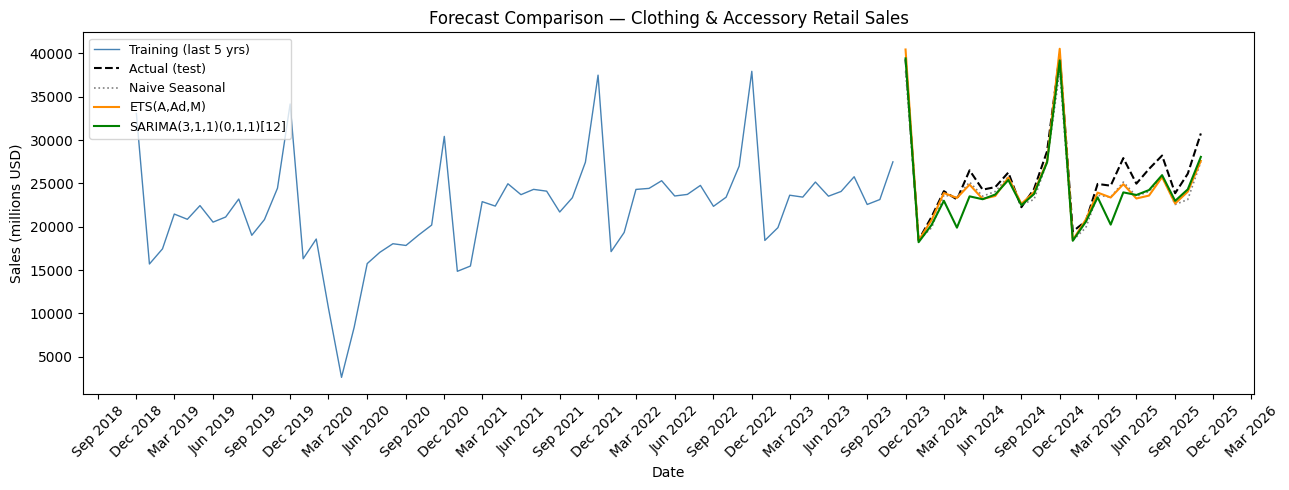

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.iloc[-60:], label='Training (last 5 yrs)', color='steelblue',  linewidth=1)
ax.plot(test,             label='Actual (test)',         color='black',      linewidth=1.5, linestyle='--')
ax.plot(naive_pred,       label='Naive Seasonal',        color='grey',       linewidth=1.2, linestyle=':')
ax.plot(ets_pred,         label='ETS(A,Ad,M)',           color='darkorange', linewidth=1.5)
ax.plot(sarima_pred,      label=sarima_label,            color='green',      linewidth=1.5)
ax.set_title('Forecast Comparison — Clothing & Accessory Retail Sales')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (millions USD)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ETS and SARIMA should both track the seasonal pattern closely
# The naïve model will lag whenever trend growth exists between years

**Comments:**  

- All three models capture the overall seasonal pattern well over the 24-month test period.  

- The main weakness is April, where SARIMA systematically drops too low. This a direct consequence of the COVID crash in April 2020 distorting its seasonal structure on the log scale!(1)

- ETS handles this better as it was fitted on the raw series, which explains its lower MAPE (4.55% vs 5.96% for SARIMA).

- The Naive model visibly lags behind in the second year as it cannot account for the slight upward trend, which explains its higher MAPE (5.07%) than ETS.

(1) To fix this, one could add a dummy variable equal to 1 for April-June 2020 and 0 elsewhere as an exogenous regressor in SARIMAX.  
This would allow the model to isolate the COVID shock and estimate the seasonal indices without it, likely bringing the April forecasts back in line with ETS.  
I try this in section 6. 

**What about forecast uncertainty?**  

I look at Prediction Intervals.

Point forecasts tell us *where* the model expects the series to go, but not how confiden it is.  
A 95% prediction interval means the model expects the true value to fall within that band 95% of the time.  
I plot 80% and 95% intervals for ETS and SARIMA, and measure empirical coverage (how often the actual test values fell inside the band).

- **ETS** intervals are computed via simulation (1 000 draws from the fitted state-space model) > no normality assumption.  
- **SARIMA** intervals are analytic (derived from the forecast standard errors) > this assumes Gaussian residuals.

I note that the COVID residual outlier violates the Gaussian assumption.

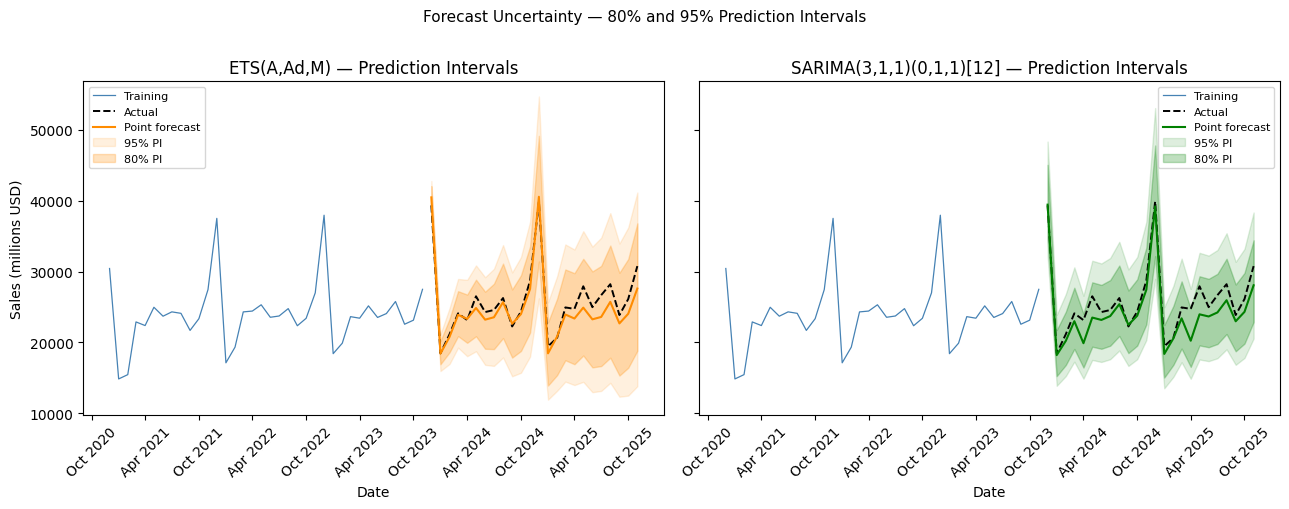

       Avg 95% PI width Avg 80% PI width 95% coverage 80% coverage
ETS               16604            10838         100%         100%
SARIMA            14563             9442         100%         100%


In [ ]:
# ETS prediction intervals via simulation 
np.random.seed(42)
sim = ets_fit.simulate(nsimulations=TEST_SIZE, repetitions=1000, anchor='end')
ets_lo95 = np.percentile(sim, 2.5,  axis=1)
ets_hi95 = np.percentile(sim, 97.5, axis=1)
ets_lo80 = np.percentile(sim, 10,   axis=1)
ets_hi80 = np.percentile(sim, 90,   axis=1)

# SARIMA prediction intervals via get_forecast (analytic, log scale → exp) 
sarima_fc   = sarima_fit.get_forecast(steps=TEST_SIZE)
ci95 = sarima_fc.conf_int(alpha=0.05)
ci80 = sarima_fc.conf_int(alpha=0.20)
s_lo95 = np.exp(ci95.iloc[:, 0]).values
s_hi95 = np.exp(ci95.iloc[:, 1]).values
s_lo80 = np.exp(ci80.iloc[:, 0]).values
s_hi80 = np.exp(ci80.iloc[:, 1]).values

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, name, point, lo95, hi95, lo80, hi80, col in [
    (axes[0], 'ETS(A,Ad,M)',   ets_pred.values,   ets_lo95, ets_hi95, ets_lo80, ets_hi80, 'darkorange'),
    (axes[1], sarima_label,    sarima_pred.values, s_lo95,   s_hi95,   s_lo80,   s_hi80,   'green'),
]:
    ax.plot(train.iloc[-36:], color='steelblue', linewidth=0.9, label='Training')
    ax.plot(test,             color='black',     linewidth=1.4, linestyle='--', label='Actual')
    ax.plot(test.index, point, color=col,        linewidth=1.5, label='Point forecast')
    ax.fill_between(test.index, lo95, hi95, color=col, alpha=0.13, label='95% PI')
    ax.fill_between(test.index, lo80, hi80, color=col, alpha=0.25, label='80% PI')
    ax.set_title(f'{name} — Prediction Intervals')
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[0].set_ylabel('Sales (millions USD)')
plt.suptitle('Forecast Uncertainty — 80% and 95% Prediction Intervals', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Coverage and width table
tv = test.values
results = {}
for name, lo95, hi95, lo80, hi80 in [
    ('ETS',    ets_lo95, ets_hi95, ets_lo80, ets_hi80),
    ('SARIMA', s_lo95,   s_hi95,   s_lo80,   s_hi80),
]:
    results[name] = {
        'Avg 95% PI width': f"{(hi95 - lo95).mean():.0f}",
        'Avg 80% PI width': f"{(hi80 - lo80).mean():.0f}",
        '95% coverage':     f"{np.mean((tv >= lo95) & (tv <= hi95)):.0%}",
        '80% coverage':     f"{np.mean((tv >= lo80) & (tv <= hi80)):.0%}",
    }
print(pd.DataFrame(results).T.to_string())


**Analysis:** 

- **Both models show very conservative intervals.** Empirical coverage was **100%** at both the **95%** and **80%** levels — meaning every single actual test value fell inside the bands.  
In theory **80% coverage** should contain ~80% of observations (roughly **19/24 months**), so **100% indicates the intervals are wider than necessary**.

- **ETS intervals are wider than SARIMA's** (avg 95% width: **16,604 vs 14,563 M USD**), despite ETS having better point accuracy. This occurs because the simulation draws from a distribution that includes **COVID-era volatility**, inflating the spread of the predictions.

- **SARIMA intervals are narrower but still overconservative.** There is an **overconfidence risk**: if another large shock occurred in the forecast period, SARIMA intervals would likely fail to contain it.

- **Interval width increases with forecast horizon**, as expected: uncertainty compounds over time, and both models show visibly wider bands in **months 13–24** than in **months 1–12**.

- **Practical implication for the CFO:**  
  The **100% coverage** is reassuring in the sense that no actual outcome fell outside the forecast range, but it also means the intervals are **too conservative to be operationally optimal** for inventory decisions. A **tighter, well-calibrated model** (or a **post-COVID refit**) would provide more actionable uncertainty ranges.

### 5.4 Residual Diagnostics

I plot in-sample residuals for each model. Ideally, they should look like white noise centred on zero with no obvious patterns or growing variance.  
The Ljung-Box p-values in the table above summarise this with stats but it's good to visualize.

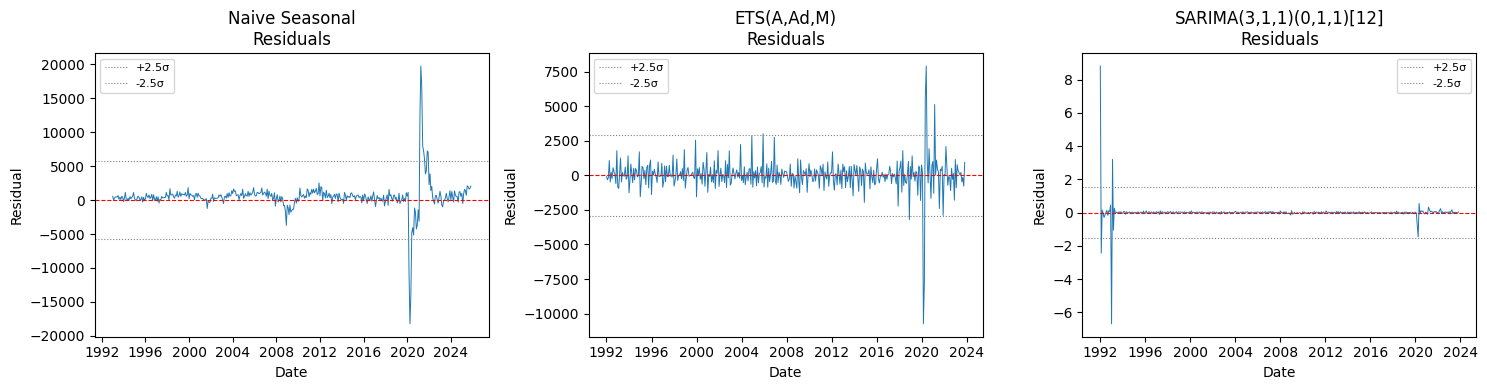

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
residual_sets = [
    ('Naive Seasonal',  naive_insample_resid),
    ('ETS(A,Ad,M)',     pd.Series(ets_fit.resid.values,    index=train.index)),
    (sarima_label,      pd.Series(sarima_fit.resid.values, index=train_log.index)),
]
for ax, (name, resid) in zip(axes, residual_sets):
    r = resid.dropna()
    std = r.std()
    ax.plot(r, linewidth=0.7)
    ax.axhline(0,      color='red',  linestyle='--', linewidth=0.8)
    ax.axhline( 2.5*std, color='grey', linestyle=':',  linewidth=0.8, label='+2.5σ')
    ax.axhline(-2.5*std, color='grey', linestyle=':',  linewidth=0.8, label='-2.5σ')
    ax.set_title(f'{name}\nResiduals')
    ax.set_xlabel('Date')
    ax.set_ylabel('Residual')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

All three plots show the same pattern: residuals are flat and close to zero everywhere except for the massive spike in 2020, which is the COVID crash.  
Note that the horizontal lines represent ±2.5 standard deviations around 0.

Outside of that single event, the residuals look like white noise with no visible trend or seasonal pattern remaining, meaning all three models fit the historical data well.  
The SARIMA residuals are on a much smaller scale (log scale) which is why the COVID spike looks proportionally larger.  
The Ljung-Box failure as seen earlier is entirely explaned by that 2020 cluster of large errors.

## Section 6 — Limitations and Further Work

**Main limitation of the models — COVID-19 structural break.**  
April–May 2020 recorded sales ~87% below what the seasonal pattern would predict, caused by mandatory retail store closures. This single observation distorts the estimated seasonal indices for spring months and inflates residual variance, widening confidence intervals and biasing the smoothing (in ETS which is the preferred model) or SARIMA parameters.

**When the preferred model may perform poorly.**  
Any model trained on this data will underforecast spring months because the COVID crash pulled the April-June seasonal factors downward. This would be especially
problematic if another large external shock occurred in the future.

**Suggested improvement.**  
Researching how to solve that issue lead us to the model tested in cell 60.  
The easy fix is to replace the "problematic" values by interpolated estimates (from adjacent years) during preprocessing, before fitting. This is essentially treating the shocks a temporary measurement anomaly. I try this in the cell below.    
Another approach to handle such shocks in training data is to add a dummy variable (here it would be value = 1 for April–June 2020, 0 elsewhere) as an "exogenous regressor" in SARIMAX to absorb the shock without contaminating the seasonal structure. 

SARIMA clean — RMSE: 1314.2  MAE: 1106.3  MAPE: 4.21%


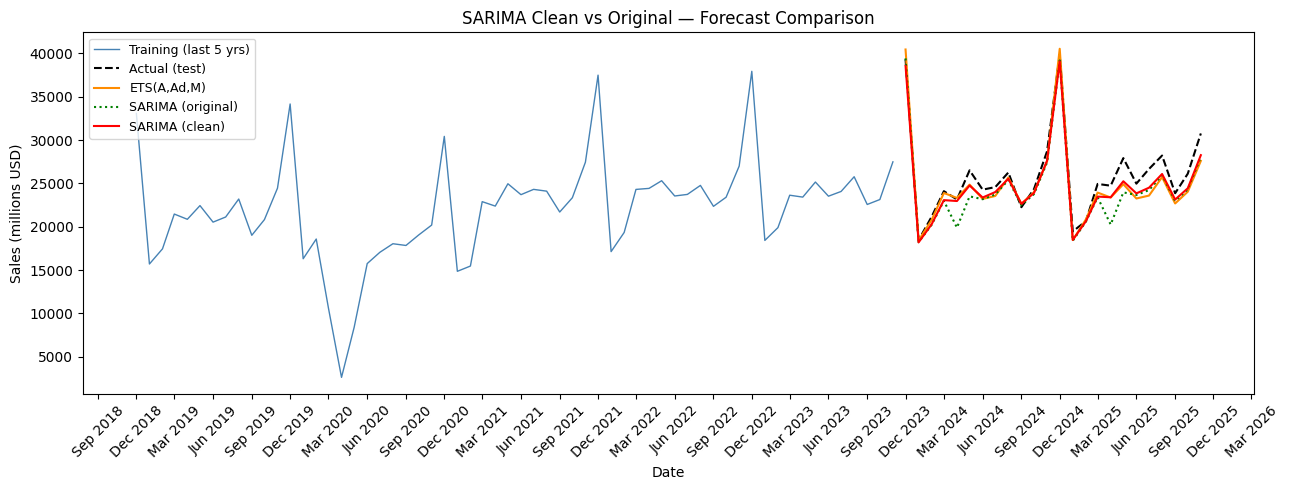

In [24]:
# TEST using interpolation for 2020-04 imputation

# replace Apr-Jun 2020 with linear interpolation from adjacent values
series_clean = series.copy()
series_clean['2020-04':'2020-06'] = np.nan
series_clean = series_clean.interpolate(method='time')

log_series_clean = np.log(series_clean)
train_clean     = series_clean.iloc[:-TEST_SIZE]
train_log_clean = log_series_clean.iloc[:-TEST_SIZE]

#refit SARIMA on the clean data
sarima_clean = SARIMAX(
    train_log_clean, order=(p, d, q),
    seasonal_order=(P, D, Q, ms),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

sarima_clean_pred = np.exp(sarima_clean.forecast(TEST_SIZE))
sarima_clean_pred.index = test.index

rmse_sc  = rmse(test, sarima_clean_pred)
mae_sc   = mae(test, sarima_clean_pred)
mape_sc  = mape(test, sarima_clean_pred)
print(f"SARIMA clean — RMSE: {rmse_sc:.1f}  MAE: {mae_sc:.1f}  MAPE: {mape_sc:.2f}%")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.iloc[-60:], label='Training (last 5 yrs)', color='steelblue',  linewidth=1)
ax.plot(test,             label='Actual (test)',         color='black',      linewidth=1.5, linestyle='--')
ax.plot(ets_pred,         label='ETS(A,Ad,M)',           color='darkorange', linewidth=1.5)
ax.plot(sarima_pred,      label='SARIMA (original)',     color='green',      linewidth=1.5, linestyle=':')
ax.plot(sarima_clean_pred,label='SARIMA (clean)',        color='red',        linewidth=1.5)
ax.set_title('SARIMA Clean vs Original — Forecast Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (millions USD)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Commentary and Final observations:**  
Interpolating the COVID months significantly improves SARIMA — MAPE drops from 5.96% to 4.21%, now beating ETS (4.55%), and the April dips are visibly fixed.

All models still struggle to capture the upward trend in the second year of the forecast (2025), systematically underestimating the December 2024 and 2025 peaks.
This is because the post-COVID recovery produced a steeper growth rate than the 30-year historical average the models were trained on, so they extrapolate a more modest trend than what actually materialised.